In [30]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
data = pd.read_csv('Data/Mall_Customers.csv', index_col=0)
X = data.iloc[:,[2,3]].values

C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'Wcss')

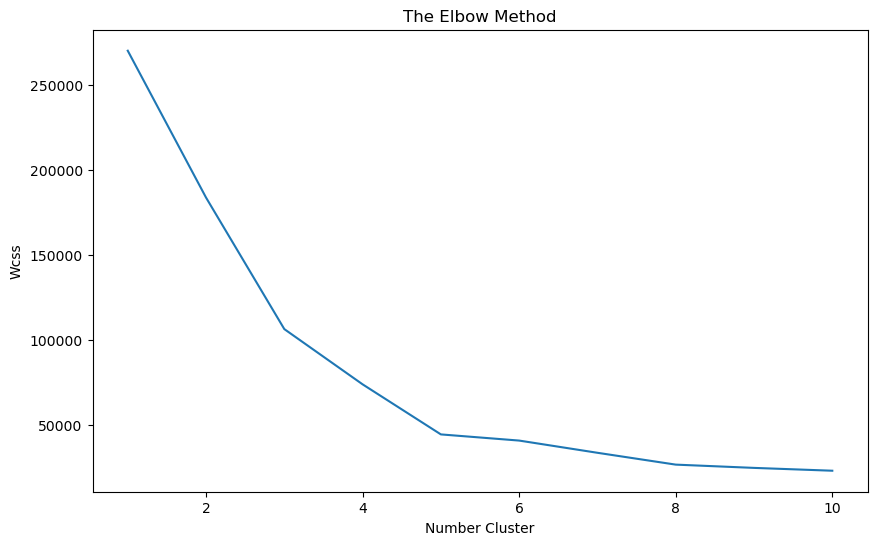

In [36]:
from sklearn.cluster import KMeans
wcss = []
max_cluster = 11

for n in range(1,max_cluster):
    kmeans = KMeans(n_clusters=n, random_state=42, init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1,max_cluster), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number Cluster')
plt.ylabel('Wcss')

In [48]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=67)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

data['n_cluster'] = y_kmeans
data.head()

C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Genre,Age,Annual Income (k$),Spending Score (1-100),n_cluster
CustomerID,,,,,
1,Male,19,15,39,2
2,Male,21,15,81,4
3,Female,20,16,6,2
4,Female,23,16,77,4
5,Female,31,17,40,2


In [54]:
kmeans.labels_
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636]])

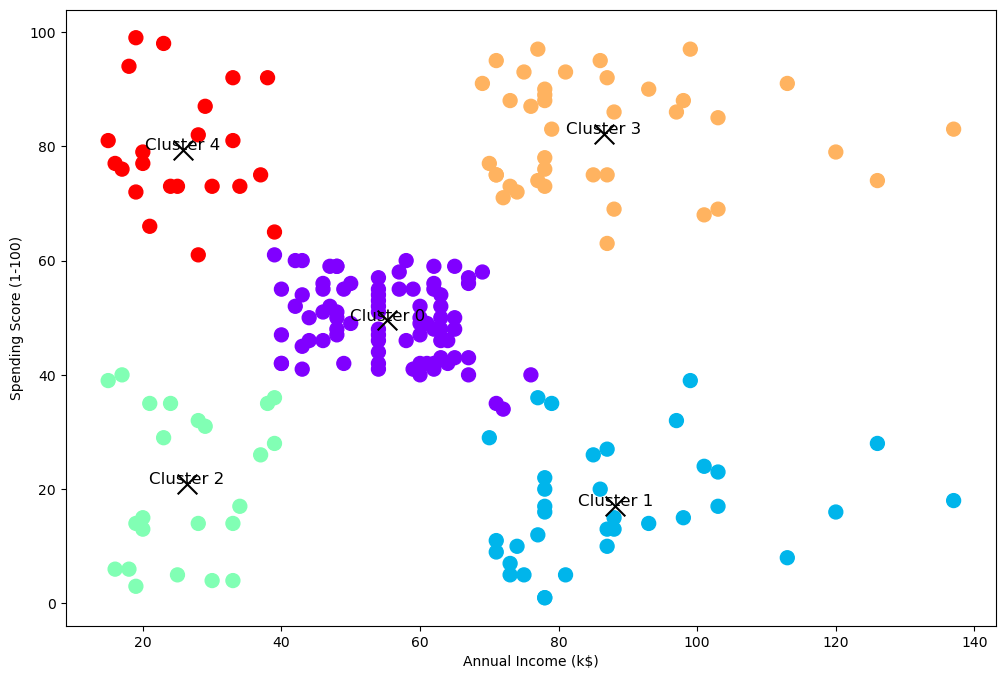

In [78]:
plt.figure(figsize=(12,8))

plt.scatter(X[:,0], X[:,1], c=y_kmeans, s=100, cmap='rainbow')

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], s=200, c='black', marker='x')

for i, center in enumerate(centers):
    plt.text(center[0], center[1], f'Cluster {i}', fontsize=12, ha='center', )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()